# California Housing: 
### Linear Regression vs. Random Forest vs. MLP

We have census data for about 20,000 California block-groups: 8 numeric features
(income, rooms, location, ...) and the target we want to predict is the median house
value.

This is a **regression** problem, not a classification one, and it's tabular (plain
numbers in a table), not images — so there is no pretrained network to borrow the way
the vision projects do. Instead we train three different models on the same data and
compare them honestly.

**Plan:**
1. Load the data and look at it before touching any model.
2. Split into train / test, and scale features only for the models that need it.
3. Train three models of increasing complexity: Linear Regression, Random Forest, MLP.
4. Compare them with three metrics (MAE, RMSE, R²), not just one.

**Dataset:** `gvlassis/california_housing` on Hugging Face — 20,640 rows, 8 features,
target = median house value. Run this on Google Colab (CPU is fine, no GPU needed).

## Why no transfer learning here

Transfer learning works because a huge, general-purpose pretraining source (ImageNet)
has already learned features — edges, textures, shapes — that transfer to almost any
new image. There is no equivalent for arbitrary tabular columns like income or room
counts: every tabular dataset has its own column meanings and scales, so there's no
"pretrained tabular model" to borrow from. Recognizing when a technique *doesn't* apply
matters as much as knowing how to use it.

## 1. Setup

In [1]:
!pip install -q datasets scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cpu


## 2. Load and inspect the data

Regression is more sensitive to data issues than classification: one wildly-scaled
feature can dominate a linear model, and a skewed or capped target can mislead you
about which metric to trust. A few minutes with `.describe()` and a histogram now
saves a confusing debugging session later.

In [2]:
from datasets import load_dataset

raw = load_dataset("gvlassis/california_housing")
print(raw)

# The dataset ships its own train/val/test splits, but we want full control over the
# split ourselves, so we recombine everything and split it our own way below.
df = pd.concat([raw[split].to_pandas() for split in raw.keys()], ignore_index=True)

print(df.shape)
df.head()


README.md:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/846k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/106k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16640 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
        num_rows: 16640
    })
    validation: Dataset({
        features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
        num_rows: 2000
    })
})
(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
TARGET = [c for c in df.columns if "value" in c.lower() or "target" in c.lower() or c.lower() == "medhouseval"]
TARGET = TARGET[0] if TARGET else df.columns[-1]
FEATURES = [c for c in df.columns if c != TARGET]
print("target column:", TARGET)
print("feature columns:", FEATURES)

df.describe().T
# Notice: features are on very different scales (Population in the thousands,
# Latitude/Longitude in the tens) -- this is why scaling matters for some models below.
# Also notice the target's max value: California housing famously caps MedHouseVal at
# 5.00 ($500k) for the top bucket, which limits how well ANY model can do on the most
# expensive homes, no matter how good it is.


target column: MedHouseVal
feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


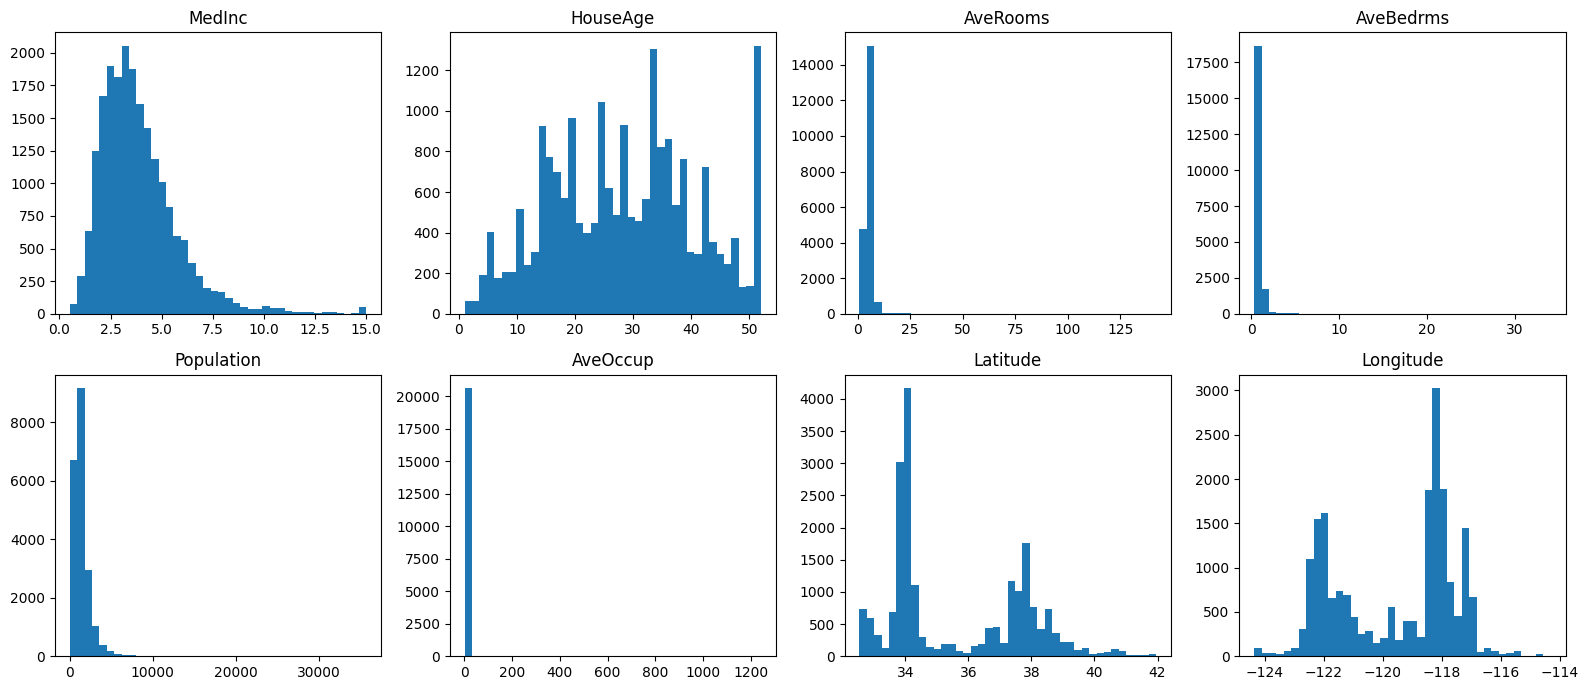

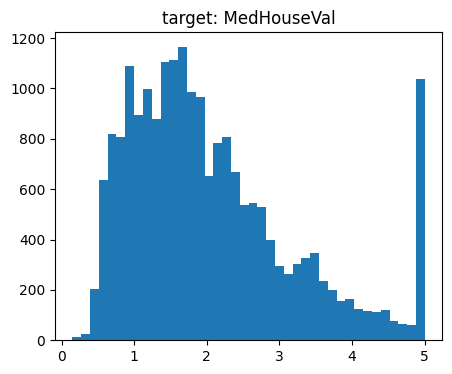

Correlation of each feature with the target:
 MedInc        0.688075
AveRooms      0.151948
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
Name: MedHouseVal, dtype: float64


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, FEATURES):
    ax.hist(df[col], bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(df[TARGET], bins=40)
ax.set_title(f"target: {TARGET}")
plt.show()

corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Correlation of each feature with the target:\n", corr)
# A cheap sanity check: MedInc (median income) should be the strongest single correlate.
# Correlation only sees straight-line relationships -- it says nothing about how features
# interact, so we keep ALL 8 features even though only one correlates strongest alone.


## 3. Train / test split — and why scaling is model-dependent

An 80/20 split, then a `StandardScaler` fit **only on the training set** (fitting it on
everything, including test data, would leak test information into training).

We'll use the scaled features for **Linear Regression** and the **MLP**, but the
**unscaled** features for the **Random Forest**:

- **Linear Regression** learns one weight per feature, and unscaled inputs make those
  weights hard to compare and the optimizer less numerically stable.
- **The MLP** trains with gradient descent — wildly different input scales produce wildly
  different gradient magnitudes per feature, which slows and destabilizes training.
- **Random Forest** splits on rules like `MedInc <= threshold`. Multiply the feature by
  1000 and the *threshold* just scales with it — the split, and every prediction, is
  completely unaffected. Trees only care about the *order* of values, never their scale,
  so scaling a tree model is wasted effort.

In [ ]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("train:", X_train.shape, " test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled = scaler.transform(X_test)         


train: (16512, 8)  test: (4128, 8)


## 4. Model 1 — Linear Regression (the baseline)

We expect this to lose to the other two, and we train it anyway: it's a required
**baseline**. If a fancier model can't clearly beat plain Linear Regression, that's a
signal something is wrong — a bug, or not enough data — not proof the fancier model
needs more tuning. Every later result gets judged relative to this baseline.

Linear Regression can only learn a straight-line relationship. It can't represent
interactions (income mattering more near the coast) or non-linear effects (diminishing
returns on extra rooms) unless you hand-engineer those features yourself.

In [6]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

lin_pred_train = lin_model.predict(X_train_scaled)
lin_pred_test = lin_model.predict(X_test_scaled)

for name, coef in sorted(zip(FEATURES, lin_model.coef_), key=lambda t: -abs(t[1])):
    print(f"{name:12s}: {coef:+.4f}")
# Because features are scaled to comparable ranges, these coefficients are now roughly
# comparable in size -- the largest |coefficient| is what the linear part of the model
# leans on most heavily.


Latitude    : -0.8969
Longitude   : -0.8698
MedInc      : +0.8544
AveBedrms   : +0.3393
AveRooms    : -0.2944
HouseAge    : +0.1225
AveOccup    : -0.0408
Population  : -0.0023


## 5. Model 2 — Random Forest Regressor

A strong, low-effort step up from a linear model: it captures non-linearities and
feature interactions automatically, and averaging many trees (an *ensemble*) reduces
the overfitting any single deep tree would suffer.

- **`n_estimators=200`** — more trees almost always reduce variance, at the cost of
  compute; 200 is a solid default for a dataset this size.
- **`min_samples_leaf=5`** instead of capping `max_depth`: this lets trees grow deep and
  expressive wherever the data supports it, but stops a leaf from memorizing a single
  outlier row.
- **`n_jobs=-1`** — every tree in a Random Forest trains independently of the others, so
  training in parallel across CPU cores is a free speedup.
- We deliberately pass in the **unscaled** features here (see Section 3).

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED,
)
rf_model.fit(X_train, y_train)   

rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

importances = sorted(zip(FEATURES, rf_model.feature_importances_), key=lambda t: -t[1])
print("Random Forest feature importances:")
for name, imp in importances:
    print(f"{name:12s}: {imp:.4f}")
# Compare this ranking to Linear Regression's coefficients above: close agreement means
# the relationship is mostly linear; disagreement on a feature suggests a non-linear or
# interaction effect the linear model can't see but the forest can.


Random Forest feature importances:
MedInc      : 0.5651
AveOccup    : 0.1384
Latitude    : 0.0861
Longitude   : 0.0854
HouseAge    : 0.0505
AveRooms    : 0.0355
Population  : 0.0196
AveBedrms   : 0.0193


## 6. Model 3 — a small MLP (Multi-Layer Perceptron)

The most flexible of the three: in principle it can learn the linear model's patterns
*plus* the Random Forest's non-linear interactions *plus* smooth combinations neither of
the other two can represent. The trade-off is it needs more careful choices and is
easier to overfit or under-train.

- **`8 -> 64 -> 32 -> 1` with ReLU:** two hidden layers is enough to combine 8 already-
  meaningful numeric features non-linearly — this isn't an image problem that needs
  dozens of layers to build up a feature hierarchy from raw pixels.
- **No activation on the output layer:** the target is a continuous house value, not a
  probability, so the last layer stays a raw linear output.
- **`MSELoss` + `Adam(lr=1e-3)`:** MSE penalizes large errors more heavily, pushing the
  optimizer to avoid big misses; Adam's adaptive learning rates converge reliably without
  a hand-tuned schedule.
- We train on the **scaled** features — unscaled `Population` values in the thousands
  next to `AveRooms` around 5-6 would produce wildly uneven gradients.

In [8]:
class HousingMLP(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(DEVICE)

mlp = HousingMLP(in_features=X_train.shape[1]).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

EPOCHS = 100
BATCH_SIZE = 256
n = X_train_t.shape[0]

train_losses = []
for epoch in range(1, EPOCHS + 1):
    mlp.train()
    perm = torch.randperm(n)
    epoch_loss = 0.0
    for i in range(0, n, BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        xb, yb = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        pred = mlp(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)

    epoch_loss /= n
    train_losses.append(epoch_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d}/{EPOCHS} | train MSE {epoch_loss:.4f}")

# 100 epochs is more than the vision projects used for fine-tuning -- that's expected.
# Each row here is just 8 numbers and the network starts from random weights (no
# pretraining to lean on), so it genuinely needs more update steps, and each epoch is
# cheap (no images to decode), so we can afford it.


epoch   1/100 | train MSE 3.6009
epoch  10/100 | train MSE 0.3811
epoch  20/100 | train MSE 0.3257
epoch  30/100 | train MSE 0.3017
epoch  40/100 | train MSE 0.2887
epoch  50/100 | train MSE 0.2819
epoch  60/100 | train MSE 0.2753
epoch  70/100 | train MSE 0.2706
epoch  80/100 | train MSE 0.2669
epoch  90/100 | train MSE 0.2617
epoch 100/100 | train MSE 0.2597


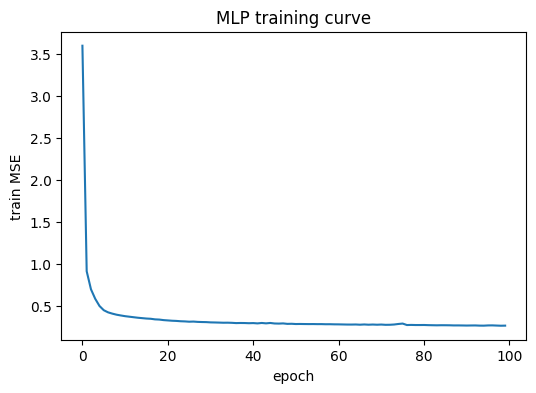

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("epoch"); plt.ylabel("train MSE"); plt.title("MLP training curve")
plt.show()

mlp.eval()
with torch.no_grad():
    mlp_pred_train = mlp(X_train_t).cpu().numpy()
    mlp_pred_test = mlp(X_test_t).cpu().numpy()


## 7. Evaluate all three models: MAE, RMSE, R²

Three metrics because they answer different questions:

- **MAE** — average absolute dollar error, in the same units as the target. The most
  directly interpretable number: "on average, we're off by $X."
- **RMSE** — also in dollars, but squares errors before averaging. If RMSE is much
  bigger than MAE, that's a sign of a handful of very bad predictions dragging the
  average up, not that the model is uniformly a bit worse everywhere.
- **R²** — fraction of the target's variance explained, unit-free and roughly 0 to 1.
  Answers "how much better than just predicting the mean?" — the number that transfers
  across datasets with different price ranges, unlike MAE/RMSE.

We compute all three on both train and test — the gap between them is the overfitting
signal.

In [10]:
def report(name, y_tr, pred_tr, y_te, pred_te):
    rows = []
    for split, yt, pt in [("train", y_tr, pred_tr), ("test", y_te, pred_te)]:
        mae = mean_absolute_error(yt, pt)
        rmse = mean_squared_error(yt, pt) ** 0.5
        r2 = r2_score(yt, pt)
        rows.append((split, mae, rmse, r2))
    print(f"\n=== {name} ===")
    print(f"{'split':6s} {'MAE':>8s} {'RMSE':>8s} {'R2':>8s}")
    for split, mae, rmse, r2 in rows:
        print(f"{split:6s} {mae:8.4f} {rmse:8.4f} {r2:8.4f}")
    return rows

results = {}
results["Linear Regression"] = report("Linear Regression", y_train, lin_pred_train, y_test, lin_pred_test)
results["Random Forest"] = report("Random Forest", y_train, rf_pred_train, y_test, rf_pred_test)
results["MLP"] = report("MLP", y_train, mlp_pred_train, y_test, mlp_pred_test)

# Expect Random Forest and MLP to both beat plain Linear Regression on test R^2 -- this
# dataset has real non-linear structure. Random Forest often edges out a modestly-sized
# MLP on tabular data like this without heavy tuning -- a common pattern; neural nets
# tend to dominate on image/text data, not small tabular datasets like this one.



=== Linear Regression ===
split       MAE     RMSE       R2
train    0.5286   0.7197   0.6126
test     0.5332   0.7456   0.5758

=== Random Forest ===
split       MAE     RMSE       R2
train    0.2151   0.3422   0.9124
test     0.3317   0.5126   0.7995

=== MLP ===
split       MAE     RMSE       R2
train    0.3440   0.5072   0.8076
test     0.3590   0.5340   0.7824


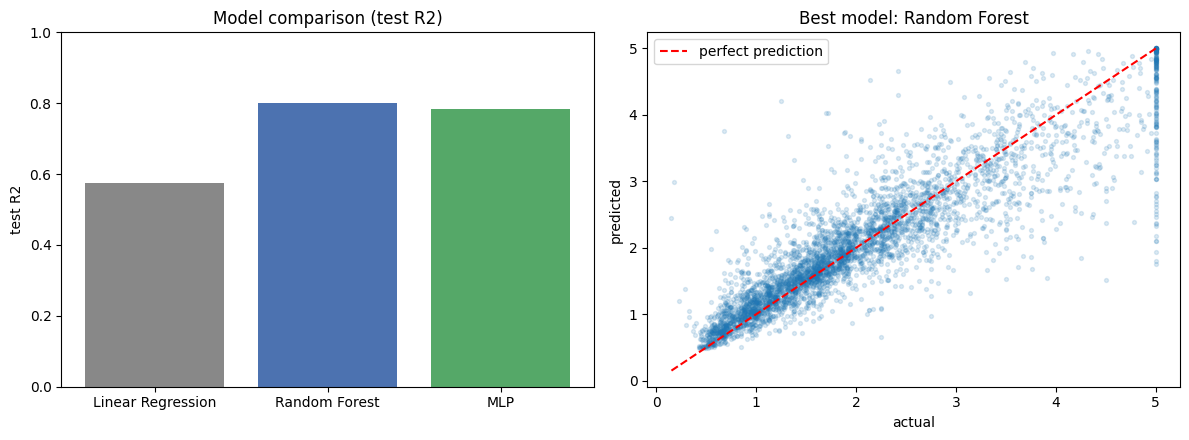

In [11]:
names = list(results.keys())
test_r2 = [results[n][1][3] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(names, test_r2, color=["#888", "#4c72b0", "#55a868"])
axes[0].set_ylabel("test R2"); axes[0].set_title("Model comparison (test R2)")
axes[0].set_ylim(0, 1)

best_name = names[int(np.argmax(test_r2))]
best_pred = {"Linear Regression": lin_pred_test, "Random Forest": rf_pred_test, "MLP": mlp_pred_test}[best_name]
axes[1].scatter(y_test, best_pred, alpha=0.15, s=8)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, "r--", label="perfect prediction")
axes[1].set_xlabel("actual"); axes[1].set_ylabel("predicted")
axes[1].set_title(f"Best model: {best_name}"); axes[1].legend()
plt.tight_layout()
plt.show()
# Look for a horizontal "shelf" of points near the top of the actual axis -- that's the
# dataset's known price cap (~$500k). The model can't predict above the cap because it
# never saw a true value above it during training. This is a property of the DATA, not
# a flaw in any of the three models.


## 8. Ideas to improve

- Feature engineering: derive `rooms_per_household`, `bedrooms_per_room`,
  `population_per_household` from the existing columns — these ratio features often
  carry more signal than the raw counts, and help all three models at once.
- Try gradient boosting (XGBoost / LightGBM / `HistGradientBoostingRegressor`) instead
  of a plain Random Forest — usually a meaningful step up on tabular data.
- Hyperparameter search for the Random Forest (`max_depth`, `min_samples_leaf`,
  `n_estimators`).
- Add `BatchNorm1d` / `Dropout` to the MLP, or try a learning-rate schedule.